## Taxi driving with DQN

In [ ]:
#!pip install gymnasium

In [ ]:
import gymnasium as gym
import numpy as np
import torch
from torch import nn
from PIL import Image
import random
import torch.nn.functional as F
import torchvision.transforms as T
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML
from IPython.display import clear_output
from time import sleep
from tqdm import tqdm

## The task: taxi-v3 from openai gym

This task involves driving a taxi on a 5x5 grid to pick up a passanger from 1 location and drop him off at a destination\
There is a more detailed explanation of the game here: 
https://gymnasium.farama.org/environments/toy_text/taxi/

Pictures and another solution can be found here: 
https://medium.com/mlearning-ai/deep-q-learning-with-pytorch-and-openai-gym-the-taxi-cab-puzzle-e7a3028f732

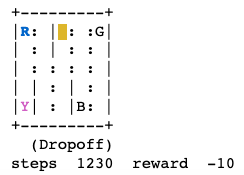

In [ ]:
env = gym.make("Taxi-v3", render_mode="ansi").env
env.reset();

We have 6 possible actions:
- 0 = Move South
- 1 = Move North
- 2 = Move East
- 3 = Move West
- 4 = Pickup passenger
- 5 = Dropoff passenger

In [ ]:
env.action_space

And 500 possible states:
- 25 possible locations for the taxi
- 5 possible locations for the passanger
- 4 possible destinations for the passanger


In [ ]:
env.observation_space

In [ ]:
env.reset()
print(env.render())

### We can do steps in our environment like this:
```python
env.step(action) # take a step in the environment
```
It returns:
- observation: the new state of the environment (number from 0 to 499)
- reward: the reward for the action
- terminated: if the episode is over
- truncated: if the episode was ended because it reached the maximum number of steps
- info: additional information

In [ ]:
env.reset()
print(env.render())
env.step(1)
print(env.render())

Rewards:
- -1 per step unless other reward is triggered.
- +20 delivering passenger.
- -10 executing “pickup” and “drop-off” actions illegally.

In [ ]:
env.reset()
print(env.render())
print("Just move: ", env.step(1)[1])
print(env.render())
print("Wrong pickup/dropoff: ", env.step(5)[1])

## Let's see a random game being played, where the actions is chosen randomly

Notice that the environment gives -1 reward for each time step where you don't finish the task, -10 reward for incorrect dropoff/pickup and +20 points for finishing the task.

The random agent can take a long time to finish the task - if you see this game being played for more than 1000+ steps, feel free to kill it and try again. sometimes it mananges to finish in under 1000 steps.

In [ ]:
def play_game(render=False, sleep_time=0.0):
    done = False
    steps = 0
    state = env.reset()
    while not done:
        steps += 1
        clear_output(wait=True)
        next_state, reward, terminated, truncated, env_info = env.step(
            env.action_space.sample()
        )
        if render:
            print(env.render())
            print("steps ", steps, " reward ", reward)
            sleep(sleep_time)
        done = terminated or truncated
        if done:
            if render:
                print("done!")
            return steps
        else:
            state = next_state

    return -99

In [ ]:
play_game(render=True, sleep_time=0.05)

## we can train an agent to "solve" this task in about 30 seconds using Q-learning (no neural network). 


This is because there are only 500 possible states in the game. We solve the game by creating a 500x6 matrix, where each state in the game (described by an integer between 0 and 499) has a quality value to each possible action. the max value determines which action we will take.

We start with all 0 "Q values" and start playing games randomly, updating the q values based on the rewards we observe, a quick but clear description of this algorithm you can read here:
https://learndatasci.com/tutorials/reinforcement-q-learning-scratch-python-openai-gym/

This algorithm learns to solve the task well in about 30 seconds of "training"

![](q_table.jpeg)

In [ ]:
# start with the all zeros table,
q_table = np.zeros([env.observation_space.n, env.action_space.n])

We know the formula for Q:
$$
Q(s,a) = r + \gamma \cdot (r_{t+1} + \gamma \cdot (r_{t+2} + \gamma \cdot (r_{t+3} + \ldots)))
$$
Which is equal to the reward of the current action plus the discounted reward of the next action.
$$
Q(s,a) = r + \gamma \cdot Q(s',a')
$$

To update Q-table we will use the following formula:
$$
Q(s,a) \leftarrow Q(s,a) + \alpha \cdot (r + \gamma \cdot \max_{a'} Q(s',a') - Q(s,a))
$$

Where:
- $Q(s,a)$ is the current Q-value for the state-action pair
- $r$ is the reward for the action
- $\alpha$ is the learning rate
- $\gamma$ is the discount factor
- $Q(s',a')$ is the Q-value for the next state-action pair

If we put $\alpha = 1$, we will obtain regular Bellman equation
$$
Q(s,a) = r + \gamma \cdot \max_{a'} Q(s',a')
$$

If we select next state based only on Q-table we could fail into a local minimum and not cover all possible states. 

To avoid this we will use epsilon-greedy policy. This means that we will select next state based on Q-table with probability 1-epsilon and with probability epsilon we will select random state.

![](Epsilon-Greedy-DQN.jpg)

In [ ]:
# training parameters
alpha = 0.1
gamma = 0.6
epsilon = 0.1

In [ ]:
steps_per_game = []

for i in range(1, 100001):
    state, info = env.reset()

    (
        epochs,
        penalties,
        reward,
    ) = (
        0,
        0,
        0,
    )
    done = False
    steps = 0

    while not done:
        steps += 1
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Explore action space
        else:
            action = np.argmax(q_table[state])  # Exploit learned values

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])

        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        q_table[state, action] = new_value

        state = next_state

        if done:
            steps_per_game.append(steps)

    if i % 100 == 0:
        clear_output(wait=True)
        print(f"Episode: {i}")

In [ ]:
# We can see that over the first 100 games the number of steps it takes to finish the game dropped dramatically

plt.plot(steps_per_game[:600])
plt.title("Steps per game")
plt.show()

### Once trained, we can see our q-table agent play the game almost perfectly

In [ ]:
def play_game(render=False, sleep_time=0.0):
    done = False
    steps = 0
    state, _ = env.reset()
    while not done:
        steps += 1
        clear_output(wait=True)
        next_state, _, terminated, truncated, _ = env.step(np.argmax(q_table[state]))
        if render:
            print(env.render())
            print("steps ", steps)
        done = terminated or truncated
        if done:
            if render:
                print("done!")
                sleep(1)
            return steps
        else:
            state = next_state
        if render:
            sleep(sleep_time)


for game_i in range(2):
    play_game(render=True, sleep_time=0.5)

In [ ]:
fig, ax = plt.subplots(figsize=(3, 8))

ax.imshow(q_table)
ax.set_aspect(0.02)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 12))

ax.imshow(q_table[:10])
ax.set_aspect(0.7)

for (j, i), label in np.ndenumerate(q_table[:10]):
    ax.text(i, j, "{0:.2f}".format(label), ha="center", va="center", fontsize=12)

We observe zero lines because there is only 400 reachable states in the game. The other 100 corresponds to the situations in which the passenger is at the same location as their destination. That's why values are 0 for all actions in those states.

In [ ]:
np.sum(np.sum(q_table, -1) == 0)

## The problem is that with more complicated environments, we don't have such a small number (500) of possible states. so the q-table is replaced with a neural network

Below we define the neural network, which take in a state (an integer between 0 and 499) and outputs 6 "q-values" for the 6 possible actions

In [ ]:
class QNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Embedding(500, 20),
            nn.Linear(20, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 6),
        )

    def forward(self, x):
        return self.layers(x)

## Define a function to choose an action based on neural network output and epsilon parameter

Notice: We divide the reward by 20, to put it in the range between -1,1

![](eps_search.jpeg)

In [ ]:
def ChooseAction(env, net, state, eps):
    if random.uniform(0, 1) < eps:
        action = env.action_space.sample()
    else:
        q, arg_q = (
            net(torch.LongTensor([state])).data.cpu().max(1)
        )  # choose max Q and matching action
        action = arg_q.item()

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    reward = reward / 20.0

    return next_state, reward, action, done

## Now we define a function to play a single game with our neural network agent, and save the memory of (state, action, reward, next state) transitions

note: this algorithm is much less efficient compared to the non-neural-net algorithm shown above, in order for the results to be seen quickly, we use

`state = env.encode(0, 0, 3, 2)`

at the start of the game.
this tell the game to always start the taxi in the same position, and to always pick up and dropoff the passanger and the same pickup/dropoff locations. this simplifies things so we can train in a few minutes

so the taxi starts at R, has to go to B, pickup, go to Y, and dropoff


In [ ]:
env.reset()

In [ ]:
print(env.render())

In [ ]:
env.unwrapped.s = env.unwrapped.encode(0, 0, 3, 2)

In [ ]:
print(env.render())

In [ ]:
def play_game_agent(agent, eps, render=False, sleep_time=0.0, set_to_fixed_state=True):
    done = False
    steps = 0
    state, _ = env.reset()
    if set_to_fixed_state:
        state = env.unwrapped.encode(0, 0, 3, 2)
        env.s = state
        env.unwrapped.s = state

    single_game_memory = []
    game_total_reward = 0

    while not done and steps < 1000:  # limit the number of steps a game can go on for
        steps += 1
        if render:
            clear_output(wait=True)

        next_state, reward, action, done = ChooseAction(env, agent, state, eps=eps)

        game_total_reward += reward
        single_game_memory.append(
            (
                torch.LongTensor([state]),
                torch.LongTensor([int(action)]),
                torch.Tensor([reward]),
                torch.LongTensor([next_state]),
                torch.Tensor([done]),
            )
        )

        if render:
            print(env.render())
            print("steps ", steps, "action ", action, " reward ", reward)
            sleep(sleep_time)

        if done:
            if render:
                print("done!")

        else:
            state = next_state
        if render and steps < 20:
            sleep(0.1)
    return single_game_memory, steps, game_total_reward

In [ ]:
qnet = QNet()
qnet.eval()

In [ ]:
play_game_agent(qnet, 0.2, render=True, sleep_time=0.05, set_to_fixed_state=True);

## We store the (state,action,reward, next state) information in a memory buffer

Let's define the class for that memory buffer.

Notice that I stored transitions with positive rewards in a different buffer, and when sampling from memory, I pick at least 1/4 of the mini-batch to have positive rewards samples. this is a simplified version of many techniques that use some variation on the sampling strategy to help DQN algorithms train faster

In [ ]:
class ReplayMemory(object):
    """Facilitates memory replay."""

    def __init__(self, capacity):
        self.capacity = capacity
        self.memory_neg = []
        self.memory_pos = []

    def push(self, m):
        positive_m = [x for x in m if x[2].item() > 0]
        negative_m = [x for x in m if x[2].item() <= 0]

        # add new memory to storage
        self.memory_neg += negative_m
        self.memory_pos += positive_m

        # if our memory is over the max size, discard the first elements
        if len(self.memory_neg) > self.capacity:
            self.memory_neg = self.memory_neg[-self.capacity :]
        if len(self.memory_pos) > self.capacity:
            self.memory_pos = self.memory_pos[-self.capacity :]

    def sample(self, bsz):
        pos_batch_size = int(min(bsz / 4, len(self.memory_pos)))

        if pos_batch_size > 0:
            pos_batch = random.sample(self.memory_pos, pos_batch_size)
        else:
            pos_batch = []

        neg_batch = random.sample(self.memory_neg, bsz - pos_batch_size)

        batch = pos_batch + neg_batch

        return map(lambda x: torch.cat(x, 0), zip(*batch))

## Now we are ready to start training our agent

Remember the cycle is this:
1. Initialize our neural network $Q(s,a, \theta)$
2. Intitalize our target network $Q(s,a, \theta^-)$ by setting $\theta^- = \theta$
3. Observe initial state $s_0$
4. For $k = 0, 1, \ldots$
    - With probability $\epsilon$ select a random action $a_k$ otherwise select $a_k = \arg\max_a Q(s_k, a, \theta)$
    - Send $a_k$ into the environment and get a reward $r_k$ and next state $s_{k+1}$
    - Add $(s_k, a_k, r_k, s_{k+1})$ to the memory buffer
    - If the memory buffer has required number of transitions do training step:
        - Sample mini-batch of transitions from memory buffer $(s, a, r, s')$
        - For each transition calculate target value $y = r + \gamma \max_{a'} Q(s', a', \theta^-)$
        - Do gradient descent step on $(y - Q(s, a, \theta))^2$
    - If $k$ is multiple of $C$ then set $\theta^- = \theta$

![](training.jpeg)

In [ ]:
### hyperparameters

max_episodes = 120
n_games_per_episode = 20
n_train_steps = 3000  # per episode

mem_capacity = 100000

initial_eps = 1.0
eps_min = 0.1
eps_decay_window = 90

batch_size = 128
gamma = 0.6

In [ ]:
env.reset()

n_actions = env.action_space.n

# create the memory buffer
mem = ReplayMemory(mem_capacity)


# and two neural networks (one to stay static while the other is training)
Qnet = QNet()
Tnet = QNet()
Tnet.load_state_dict(Qnet.state_dict())


opt = torch.optim.Adam(Qnet.parameters(), lr=5e-4)

Qnet.train()
Tnet.eval()

eps = initial_eps
eps_delta = (eps - eps_min) / eps_decay_window

## This is how the epsilon decay will look

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

eps_i = []
for epsisode_i in range(max_episodes):
    eps_i.append(max(eps_min, initial_eps * np.exp(-eps_delta * epsisode_i)))

ax.plot(eps_i)
ax.set_ylim(0, 1)
ax.set_xlabel(
    "episode (a set of " + str(n_games_per_episode) + " games played before training)"
)
ax.set_ylabel("eps")
plt.show()

## Fill the memory buffer with random games

Only keep games that manages to randomly finish in under 1500 steps

In [ ]:
collected_games = 0
while collected_games < 20:
    game_memory, steps, rewards = play_game_agent(Qnet, 1, render=False)

    if steps < 1000:
        mem.push(game_memory)
        collected_games += 1

## Perform an initial training where we aim for the Q values to be just the immediate reward (without confusing it with the initial Q values given by the network)

In [ ]:
Qnet.train()
for train_step_i in tqdm(range(5000)):
    opt.zero_grad()

    bs, ba, br, bns, bdone = mem.sample(batch_size)

    bq = Qnet(bs).gather(1, ba.unsqueeze(1)).squeeze(1)

    # normally, you would use the existing Q value given by the network to compute the next step Q value
    # but for the intiail training we assume the next Q value is 0, this helps start the training on the right foot
    # bnq = Tnet(bns).detach().max(1)[0] * gamma * (1 - bdone)
    loss = F.smooth_l1_loss(bq, br)
    loss.backward()
    opt.step()

## let's visualize the inital training to make it clear what it did:

In [ ]:
Qnet.eval()

batch_rewards = []
batch_qs = []

for eval_step_i in range(300):
    bs, ba, br, bns, bdone = mem.sample(batch_size)

    bq = Qnet(bs).gather(1, ba.unsqueeze(1)).squeeze(1)

    bg = list(bq.data.numpy().flatten())

    batch_qs += bg

    br = list(br.data.numpy().flatten())

    batch_rewards += br


fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(batch_rewards, batch_qs)
ax.plot([-1, 1], [-1, 1], c="r")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel("immediate reward")
ax.set_ylabel("Qnet prediction")

plt.show()

In [ ]:
Qnet.train()


avg_game_steps_history = []


for episode_i in range(max_episodes):
    steps_per_game = []
    reward_per_game = []

    cur_eps = max(eps_min, initial_eps * np.exp(-eps_delta * epsisode_i))

    # play X games
    for game_i in range(n_games_per_episode):
        game_memory, steps, rewards = play_game_agent(Qnet, cur_eps, render=False)

        mem.push(game_memory)
        steps_per_game.append(steps)
        reward_per_game.append(rewards)

    print(
        "episode ",
        episode_i + 1,
        " avg steps per game ",
        np.mean(steps_per_game),
        " avg rewards ",
        np.mean(reward_per_game),
    )
    if np.mean(steps_per_game) < 30:
        print("solved!")
        break

    # save the sate of the neural network at the start of the episode
    # if episode_i % 2 == 0:
    Tnet.load_state_dict(Qnet.state_dict())
    # train the network
    for train_step_i in range(n_train_steps):
        opt.zero_grad()

        bs, ba, br, bns, bdone = mem.sample(batch_size)

        bq = Qnet(bs).gather(1, ba.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            bnq = Tnet(bns).detach().max(1)[0] * gamma * (1 - bdone)
        loss = F.smooth_l1_loss(bq, br + bnq)

        loss.backward()

        opt.step()

## Now let's watch our NN play the game (remember we gave a fixed starting condition)

In [ ]:
Qnet.eval()

# eps=0 means the neural network is totally in charge
play_game_agent(Qnet, eps=0, render=True, sleep_time=0.01, set_to_fixed_state=True);

In [ ]:
# torch.save(Qnet.state_dict(),'qnet.pt')

In [ ]:
Qnet = QNet();

In [ ]:
Qnet.load_state_dict(torch.load("qnet.pt"))

In [ ]:
Qnet.eval();

In [ ]:
play_game_agent(Qnet, eps=0, render=True, sleep_time=0.1);